In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import json
import reprlib

In [2]:
df = pd.read_csv('../preprocessing/cleaned_text.csv')
df.drop(columns=['full_text', 'case_folding', 'tokens', 'normalized', 'stopword_removal'], inplace=True)


In [3]:
# Cek data duplikat
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

# Cek data kosong
print(f"Jumlah data kosong: {df.isnull().sum().sum()}")

# Tampilkan data yang duplikat
duplicate_data = df[df.duplicated()]
print("Data duplikat:")
print(duplicate_data)

# menghapus data duplikat
df.drop_duplicates(inplace=True)
print(f'Jumlah data duplikat: {df.duplicated().sum()}')
print(f"Jumlah data setelah menghapus duplikat: {len(df)}")

Jumlah data duplikat: 67
Jumlah data kosong: 0
Data duplikat:
                                               stemming
36    ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...
62    ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...
74    ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...
114   ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...
125   ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...
...                                                 ...
1138                  ['yokai', 'btc', 'yokaiavengers']
1142                                            ['btc']
1147  ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...
1167  ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...
1223  ['umum', 'umum', 'harga', 'bitcoin', 'rp', 'mi...

[67 rows x 1 columns]
Jumlah data duplikat: 0
Jumlah data setelah menghapus duplikat: 1169


In [ ]:
with open('../../sentistrength_id/_json_sentiwords_id.txt') as f:
    lexicon = f.read()

sentis = json.loads(lexicon)

sentis

In [10]:
def label_sentis(tokens, sentis):
    skor = 0.0
    word_found = []


    if isinstance(tokens, str):
        try:
            tokens = ast.literal_eval(tokens)
        except (ValueError, SystemError):
            tokens = str(tokens).split()

    for word in tokens:
        word_lower = str(word).lower()

        if word_lower in sentis:
            skor += sentis[word_lower]
            word_found.append(f"{word_lower}({sentis[word_lower]})")

    if skor > 0:
        label = 'positive'
        nilai_label = 1
    else:
        label = 'negative'
        nilai_label = -1

    return label, nilai_label, ", ".join(word_found)

results = df['stemming'].apply(lambda x: label_sentis(x, sentis))

df['sentis'] = [r[0] for r in results]
df['nilai_sentis'] = [r[1] for r in results]
df['matched_words'] = [r[2] for r in results]

print(df[['stemming', 'sentis', 'nilai_sentis', 'matched_words']].head())

                                            stemming    sentis  nilai_sentis  \
0  ['chale', 'man', 'start', 'dey', 'crypto', 'fo...  negative            -1   
1                ['bitcoin', 'orange', 'ogsatoshis']  negative            -1   
2  ['wahyus', 'problem', 'besar', 'selesai', 'web...  positive             1   
3  ['boomer', 'bilang', 'underwear', 'eh', 'under...  negative            -1   
4  ['ek', 'aisi', 'wife', 'main', 'bhi', 'deserve...  negative            -1   

                    matched_words  
0                                  
1                                  
2  besar(3), risiko(-3), besar(3)  
3                                  
4                                  


In [12]:
print(df['sentis'].value_counts())

sentis
negative    896
positive    273
Name: count, dtype: int64


In [ ]:
sia = SentimentIntensityAnalyzer()
sia.lexicon.clear()

with open('../../sentistrength_id/_json_sentiwords_id.txt') as f:
    lexicon = f.read()

sentis = json.loads(lexicon)

sia.lexicon.update(sentis)
print(f"Jumlah kata dalam lexicon: {len(sia.lexicon)}")
print(reprlib.repr(sia.lexicon))

def is_positive_senti(tweet: str) -> bool:
    """True if tweet has positive compound sentiment, False otherwise."""
    return sia.polarity_scores(tweet)["compound"] > 0
# Menulis hasil label untuk setiap kalimat berdasarkan nilai compound dari SentiStrength
#Mengubah bentuk dataframe menjadi string(kalimat utuh)
df['stemming'] = [' '.join(eval(str)) for str in df['stemming'].values]

for tweet in df['stemming']:
    if is_positive_senti(tweet) == True:
        label = "pos"
    else:
        label = "neg"
    df.loc[df['stemming'] == tweet, 'senti'] = label

df

Jumlah kata dalam lexicon: 1729
{'abadi': 5, 'absen': -3, 'abu-abu': -1, 'acuh': 4, ...}


In [21]:
print(df['senti'].value_counts())

senti
neg    896
pos    273
Name: count, dtype: int64


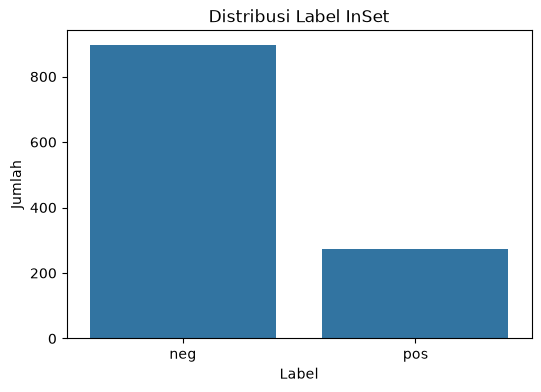

In [20]:
# display distribusi label
plt.figure(figsize=(6,4))
sns.countplot(x='senti', data=df)
plt.title('Distribusi Label InSet')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.show()